# Lab6 Henrik

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, roc_auc_score

In [14]:
url = 'data/student_performance.csv'
df = pd.read_csv(url, sep=',')
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [12]:
df.shape

(649, 33)

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [5]:
df.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

<Axes: ylabel='G3'>

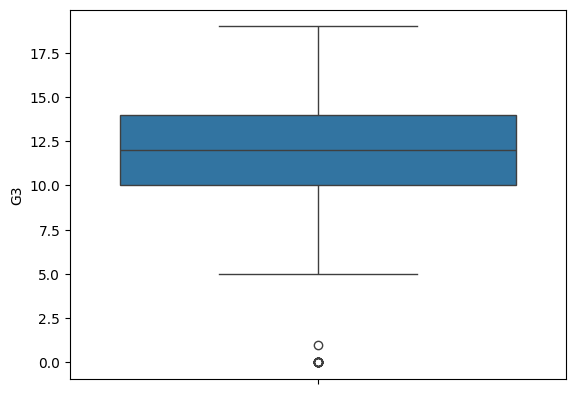

In [8]:
sns.boxplot(data=df, y='G3')

<Axes: xlabel='G3', ylabel='count'>

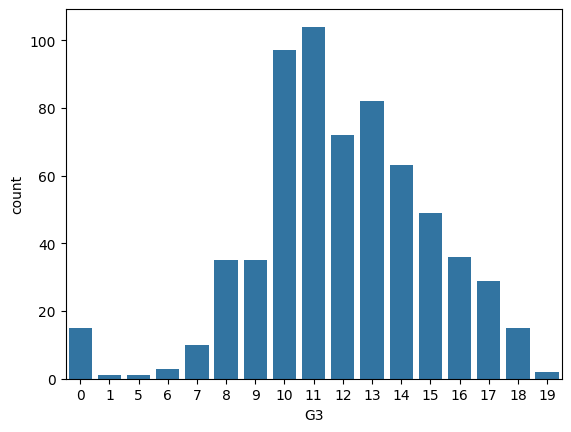

In [15]:
sns.countplot(data=df, x='G3')

In [16]:
df.rename(columns={'G1': 'period_1_grades', 'G2': 'period_2_grades', 'G3': 'final_grade'}, inplace=True)

In [17]:
df['passed'] = df['final_grade'].apply(lambda x: True if x >= 10 else False)

In [23]:
df['passed'].value_counts()

passed
True     549
False    100
Name: count, dtype: int64

In [26]:
print('Percentage passed:', round((549/(549+100)*100), 2))

Percentage passed: 84.59


In [18]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,period_1_grades,period_2_grades,final_grade,passed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11,True
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11,True
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12,True
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14,True
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13,True


In [19]:
numerical_columns = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'period_1_grades', 'period_2_grades']

In [20]:
df_num = df[numerical_columns + ['passed']]

In [22]:
df_num.isnull().sum()


age                0
Medu               0
Fedu               0
traveltime         0
studytime          0
failures           0
famrel             0
freetime           0
goout              0
Dalc               0
Walc               0
health             0
absences           0
period_1_grades    0
period_2_grades    0
passed             0
dtype: int64

In [27]:
X = df_num.drop(columns=['passed'])
y = df_num['passed']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [31]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Accuracy:", accuracy_dt)
print("Confusion Matrix:")
print(cm_dt)

Accuracy: 0.9282051282051282
Confusion Matrix:
[[ 20   6]
 [  8 161]]


In [32]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)
print("Confusion Matrix:")
print(cm_rf)


Accuracy: 0.9384615384615385
Confusion Matrix:
[[ 19   7]
 [  5 164]]


In [33]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Accuracy:", accuracy_nb)
print("confusion_matrix:")
print(cm_nb)

Accuracy: 0.9076923076923077
confusion_matrix:
[[ 20   6]
 [ 12 157]]


(0.0, 1.0)

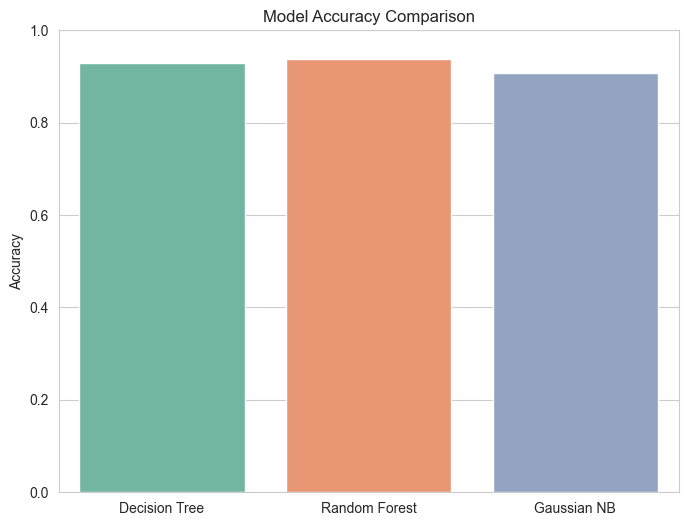

In [45]:

accuracies = {
    'Decision Tree': accuracy_dt,
    'Random Forest': accuracy_rf,
    'Gaussian NB': accuracy_nb
}

models = list(accuracies.keys())
scores = list(accuracies.values())

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=scores, palette="Set2", hue=models)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)


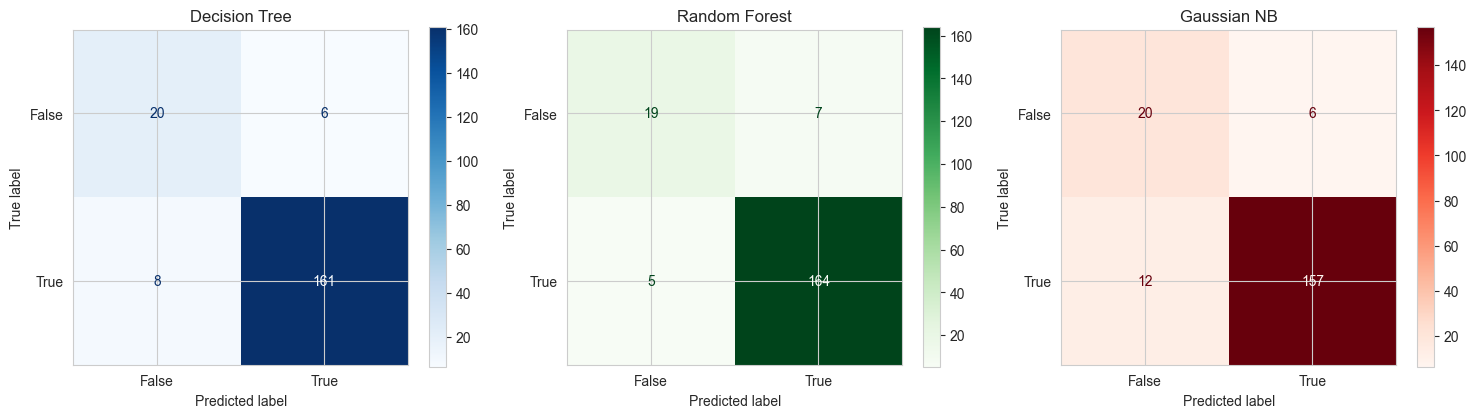

In [41]:

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
class_labels = ['False', 'True']
ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=class_labels).plot(ax=axes[0], cmap='Blues')
axes[0].set_title("Decision Tree")

ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_labels).plot(ax=axes[1], cmap='Greens')
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=class_labels).plot(ax=axes[2], cmap='Reds')
axes[2].set_title("Gaussian NB")

plt.tight_layout()


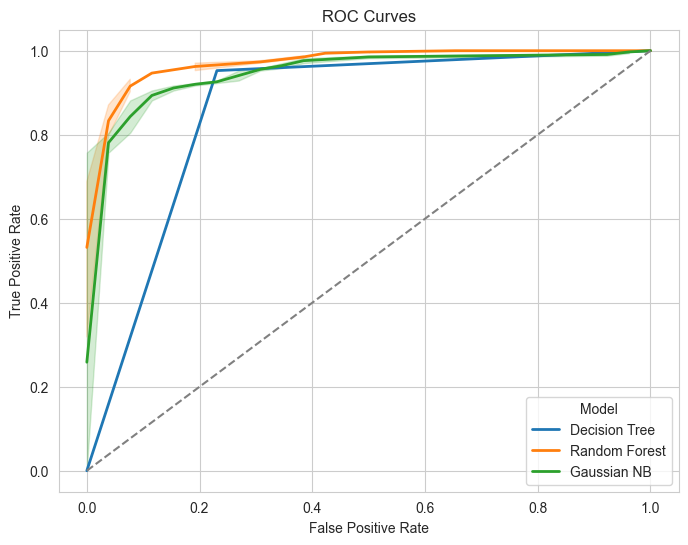

AUC Scores: Decision Tree=0.86, Random Forest=0.98, Gaussian NB=0.95


In [46]:

# Example: predictions for three models
y_pred_dt = dt.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict_proba(X_test)[:, 1]
y_pred_nb = nb.predict_proba(X_test)[:, 1]

# Compute ROC data
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_nb)

auc_dt = roc_auc_score(y_test, y_pred_dt)
auc_rf = roc_auc_score(y_test, y_pred_rf)
auc_nb = roc_auc_score(y_test, y_pred_nb)

# Combine into DataFrame
roc_df = pd.DataFrame({
    'fpr': list(fpr_dt) + list(fpr_rf) + list(fpr_nb),
    'tpr': list(tpr_dt) + list(tpr_rf) + list(tpr_nb),
    'model': (['Decision Tree'] * len(fpr_dt) +
              ['Random Forest'] * len(fpr_rf) +
              ['Gaussian NB'] * len(fpr_nb))
})

# Plot with Seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.lineplot(data=roc_df, x='fpr', y='tpr', hue='model', linewidth=2)

# Add diagonal line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(title='Model')
plt.show()

print(f"AUC Scores: Decision Tree={auc_dt:.2f}, Random Forest={auc_rf:.2f}, Gaussian NB={auc_nb:.2f}")


               Mean Accuracy   Mean F1
Decision Tree       0.892093  0.935528
Random Forest       0.927537  0.957446
Gaussian NB         0.882815  0.928099


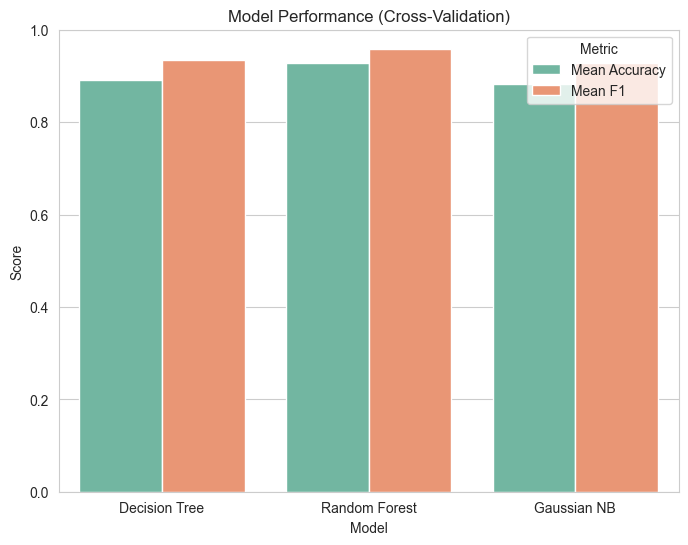

In [48]:

models = {
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gaussian NB': nb
}

# Reusable function for cross-validation
def evaluate_models(models, X, y, cv=5):
    results = {}
    for name, model in models.items():
        cv_results = cross_validate(model, X, y, cv=cv, scoring=['accuracy', 'f1'], n_jobs=-1)
        results[name] = {
            'Mean Accuracy': cv_results['test_accuracy'].mean(),
            'Mean F1': cv_results['test_f1'].mean()
        }
    return results

# Example usage
results = evaluate_models(models, X, y, cv=5)

# Display results
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df)

# Optional: Visualize comparison
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.barplot(data=results_df.reset_index().melt(id_vars='index'),
            x='index', y='value', hue='variable', palette='Set2')
plt.title('Model Performance (Cross-Validation)')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.show()
